In [2]:
import numpy as np
import nibabel as nb
import nitools as nt
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import surfAnalysisPy as surf
import os
import globals as gl

NameError: name 'gl' is not defined

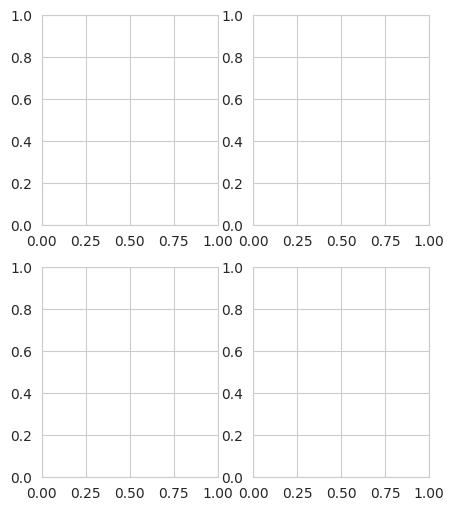

In [3]:
glm = 12
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(5, 6))
sn = 108
experiment = 'smp2'
dtype = 'con'

vmin, vmax = -20, 20

xlim = {
    'L': [-80, 120],
    'R': [-120, 80],
}
ylim = {
    'L': [-50, 150],
    'R':[-60, 140]
}

for H, Hem in enumerate(['L', 'R']):

    data = os.path.join(gl.baseDir, experiment, gl.wbDir, f'subj{sn}', f'glm{glm}.{dtype}.{Hem}.func.gii')

    D = nb.load(data)
    darray = nt.get_gifti_data_matrix(D)

    col_names = nt.get_gifti_column_names(D)

    plan_col_names = [f'con_{col}.nii' for col in ['0%', '25%', '50%', '75%', '100%']]
    exec_col_names = [f'con_{col}.nii' for col in ['0%,index', '25%,index', '50%,index', '75%,index', '100%,index', '0%,ring', '25%,ring', '50%,ring', '75%,ring', '100%,ring']]

    im = np.array([x in plan_col_names for x in col_names])
    darray_avg = np.array(darray[:, im]).mean(axis=1)
    plt.sca(axs[0, H])
    surf.plot.plotmap(darray_avg, f'fs32k_{Hem}',
                      underlay=None,
                      borders=gl.borders[Hem],
                      cscale=[vmin, vmax],
                      cmap='jet',
                      underscale=[-1.5, 1],
                      alpha=.5,
                      new_figure=False,
                      colorbar=False,
                      frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]])

    im = np.array([x in exec_col_names for x in col_names])
    darray_avg = np.array(darray[:, im]).mean(axis=1)
    plt.sca(axs[1, H])
    surf.plot.plotmap(darray_avg, f'fs32k_{Hem}',
                      underlay=None,
                      borders=gl.borders[Hem],
                      cscale=[vmin, vmax],
                      cmap='jet',
                      underscale=[-1.5, 1],
                      alpha=.5,
                      new_figure=False,
                      colorbar=False,
                      frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]])

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='jet')
cbar = fig.colorbar(sm, ax=[axs[1, 0], axs[1, 1]], orientation='horizontal', fraction=0.03)
cbar.set_label('activation vs. baseline')

# cosmetic
axs[0, 0].set_title('Left hemisphere\nPlanning')
axs[0, 1].set_title('Right hemisphere\nPlanning')
axs[1, 0].set_title('Execution')
axs[1, 1].set_title('Execution')

fig.suptitle(f'Average activation vs. baseline (participant {sn})')
fig.subplots_adjust(top=0.85, bottom=.2)
